# Notebook 2: Variational Monte Carlo from scratch

In this notebook, we will implement a complete variational Monte Carlo (VMC) algorithm from scratch using JAX and apply it to the one-dimensional transverse-field Ising (TFI) model.

The goal is not to build the most efficient implementation possible, but rather to understand the fundamental ingredients underlying modern neural-quantum-state algorithms. Starting from a simple variational wavefunction, we will progressively construct all the components required for VMC. By the end of the notebook, we will have assembled a minimal but complete VMC engine and will be able to compare ordinary gradient descent with stochastic reconfiguration on a concrete quantum many-body problem.

## 1. Transverse-field Ising model

Throughout this notebook, we consider the following one-dimensional transverse-field Ising model:

$\hat{H} = -\sum_{i=1}^L \hat{\sigma}_i^z \hat{\sigma}_{i+1}^z - g \sum_{i=1}^L \hat{\sigma}_i^x .$

An important point is that, with the above sign convention, the off-diagonal matrix elements generated by the transverse field are all non-positive. By the Perron-Frobenius theorem, the ground-state wavefunction can thus be chosen to be real and non-negative in the computational basis. To simplify matters, we then focus exclusively on modelling the amplitudes of the wavefunction and do not need to consider complex phases.

For pedagogical purposes, we will work with relatively small system sizes. This will allow us to compare Monte Carlo estimates against exact sums over all ($2^L$) spin configurations, providing useful sanity checks as we build the VMC algorithm.

In [1]:
import jax
import jax.numpy as jnp

L = 12
g = 1.0

A spin configuration is represented by a vector

$$\sigma = (\sigma_1,\ldots,\sigma_L), \qquad \sigma_i\in\{-1,+1\}.$$

For small systems, we can explicitly enumerate all ($2^L$) configurations.

In [2]:
def all_configurations(L, dtype=jnp.int8):
    """Enumerate all spin configurations σ_i ∈ {-1, +1}."""
    # Integers 0, ..., 2^L - 1, one per configuration
    states = jnp.arange(2**L)[:, None]
    # Extract the binary digits of each integer.
    # The result has shape (2^L, L) and contains only 0s and 1s.
    bits = (states >> jnp.arange(L)) & 1
    # Convert binary digits {0, 1} to spins {-1, +1}
    return (2 * bits - 1).astype(dtype)

configs = all_configurations(L)

# configs.shape == (2**L, L)
print(configs.shape)

# First five configurations
configs[:5]

(4096, 12)


Array([[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [ 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [-1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [ 1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [-1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1]], dtype=int8)

## 2. Trial wavefunction

In VMC, we represent the quantum state through a parametrised wavefunction $\psi_{\theta}(\sigma)$. Since the ground state of the transverse-field Ising model can be chosen positive in the computational basis, we will directly parametrise the logarithm of the wavefunction amplitude, $\log \psi_{\theta}(\sigma)$. Working with $\log\psi_{\theta}$ is numerically convenient and will also help us write numerically stable code.

We use a restricted Boltzmann machine ansatz:

$$\log \psi_{\theta}(\sigma) = \sum_i a_i \sigma_i + \sum_j \log\cosh\left(b_j + \sum_i W_{ij}\sigma_i\right),$$

where the parameters are the visible biases $a_i$, hidden biases $b_j$, and weights $W_{ij}$. 

In JAX, model parameters are typically organised into *Pytrees*: nested Python containers (such as dictionaries, lists, or tuples) whose leaves are JAX arrays. Pytrees provide a convenient abstraction for working with large collections of parameters, as JAX transformations such as automatic differentiation, vectorisation, and optimisation naturally operate on them.

For the RBM, we store the visible biases `a`, hidden biases `b`, and weight matrix `W` in a dictionary. Below, we can generate a set of randomly initialised parameters in a way very similar to that of the literature:

In [3]:
def init_rbm_params(key, L, alpha=2, stddev=0.01):
    M = alpha * L

    k1, k2, k3 = jax.random.split(key, 3)

    return {
        "a": stddev * jax.random.normal(k1, (L,)),
        "b": stddev * jax.random.normal(k2, (M,)),
        "W": stddev * jax.random.normal(k3, (L, M)),
    }

key = jax.random.PRNGKey(0)
key, subkey = jax.random.split(key)

params = init_rbm_params(subkey, L)

One can apply functions to all leaves of a Pytree with `jax.tree.map`. Let us use that to show the structure and shape of the set of parameters:

In [4]:
print("Parameters shape: ", jax.tree.map(lambda x: x.shape, params))

n_params = sum(x.size for x in jax.tree.leaves(params))
print(f"Number of parameters: {n_params}")

print("Hilbert-space dimension: ", configs.shape[0]) 

Parameters shape:  {'W': (12, 24), 'a': (12,), 'b': (24,)}
Number of parameters: 324
Hilbert-space dimension:  4096


Let us now code the RBM wavefunction that takes a Pytree of parameters and a single configuration and produces the corresponding wavefunction amplitude:

In [5]:
def logpsi_single(params, sigma):
    # shapes: (alpha * L,) + (L,) @ (L, alpha * L) -> (alpha * L,)
    theta = params["b"] + sigma @ params["W"]
    # shapes: (L,) @ (L,) + scalar -> scalar
    logvalue = sigma @ params["a"] + jnp.sum(jnp.log(jnp.cosh(theta)))
    return logvalue

config = configs[0]
print("config: ", config)
print("logpsi: ", logpsi_single(params, configs[0]))

config:  [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
logpsi:  0.024511285


We now want to evaluate the wavefunction on all configurations in our batch (here, all configurations of the Hilbert space).

In the present case, a manually vectorised implementation would be straightforward because matrix multiplication naturally supports batching. However, deriving batched implementations quickly becomes tedious for more complicated functions.

Instead, JAX provides the `vmap` transformation, which automatically lifts a function acting on a single configuration into a function acting on a batch of configurations.

In [6]:
logpsi = jax.vmap(logpsi_single, in_axes=(None, 0))
logvalues = logpsi(params, configs)

print(logvalues.shape)
logvalues

(4096,)


Array([0.02451129, 0.0335076 , 0.01050396, ..., 0.03356557, 0.01938985,
       0.01737342], dtype=float32)

The argument `in_axes=(None, 0)` means do not vectorise over `params` but do vectorise over the leading axis of `configs`.

From now on, we will use this vectorised version whenever we need to evaluate the wavefunction on many configurations simultaneously.

## 3. Exact *full-sum* expectation values

Given a wavefunction $\psi_\theta(\sigma)$, we can construct the Born probability distribution

$$p_\theta(\sigma) = \frac{|\psi_\theta(\sigma)|^2}{\sum_{\sigma'} |\psi_\theta(\sigma')|^2}.$$

Since we have enumerated all configurations, we can compute this distribution exactly.

In [7]:
logvalues = logpsi(params, configs)

def logprobs(logvalues, normalize=True):
    _logprobs = 2 * jnp.real(logvalues)
    if normalize:
        # Stable normalisation
        _logprobs -= jax.scipy.special.logsumexp(_logprobs)
    return _logprobs

probs = jnp.exp(logprobs(logvalues))

print("normalisation:", probs.sum())

normalisation: 0.99999994


We can readily evaluate some physical quantities on our first variational state! For instance, let us consider the total magnetisation $M_z(\sigma) = \frac{1}{L}\sum_i \sigma_i$ of the state. The expectation value can now be computed exactly as

$$\langle \hat{M}_z \rangle = \sum_\sigma p_\theta(\sigma)\, M_z(\sigma).$$

In [8]:
magnetisation = jnp.mean(configs, axis=-1)

m = jnp.sum(probs * magnetisation)

print(m)

-0.0005851388


## 4. Local energy

Unlike the magnetisation, the Hamiltonian is not diagonal in the computational basis because of the transverse-field term. The variational energy therefore cannot be written directly as the classical expectation value of a function of the spin configuration. A central idea of variational Monte Carlo is that the energy can nevertheless be expressed as an expectation value over the Born probability distribution through the introduction of the local energy:

$$E_{\mathrm{loc}}(\sigma) = \sum_{\sigma'} H_{\sigma,\sigma'} \frac{\psi_\theta(\sigma')}{\psi_\theta(\sigma)}.$$

Then, one has

$$E_\theta = \sum_\sigma p_\theta(\sigma) E_{\mathrm{loc}}.$$

The local energy is therefore the central quantity that must be evaluated during a VMC simulation.

Importantly, despite the apparent summation over all configurations $\sigma'$ in the above definition, for any given configuration $\sigma$, one can restrict that sum only to its connected elements $\sigma'$ through the Hamiltonian $\hat{H}$, that is such that $H_{\sigma,\sigma'} := \langle \sigma|\hat{H}|\sigma'\rangle \neq 0$.

To evaluate the local energy on a configuration $\sigma$, we need to know which configurations $\sigma'$ are connected by the Hamiltonian and their contribution $H_{\sigma,\sigma'}$ to $E_\mathrm{loc}(\sigma)$. For the transverse-field Ising model, there are two types of contributions:

1. The diagonal interaction term connects $\sigma$ to itself,

$$\sigma'=\sigma, \qquad H_{\sigma,\sigma} = -\sum_i \sigma_i\sigma_{i+1}.$$

2. The transverse-field term flips one spin at a time. If $\sigma^{(i)}$ denotes the configuration obtained from $\sigma$ by flipping spin $i$, then we have the following pairs of connected elements and their corresponding matrix elements:
$$\lbrace (\sigma^{(i)}, -g)\rbrace_{i=1}^{L}$$
Thus, each configuration is connected to itself and to the $L$ configurations obtained by single-spin flips, with the same local-energy contribution $-g$.

Let us code this:

In [9]:
def get_mels_and_conns(sigma, g):
    sigma_shifted = jnp.roll(sigma, -1)
    e_diag = -jnp.sum(sigma * sigma_shifted)

    # matrix elements
    matrix_elements = jnp.concatenate([
        jnp.array([e_diag]),  # diagonal
        -g * jnp.ones(L),     # off-diagonal
    ])

    # -1 on the diagonal, +1 everywhere else
    flip_masks = 1 - 2 * jnp.eye(L, dtype=sigma.dtype)
    
    # connected elements
    connected = jnp.concatenate([
        sigma[None, :],       # identity
        sigma * flip_masks,   # one-spin flipped
    ])

    return matrix_elements, connected

# Let us try:
get_mels_and_conns(configs[0], g)

(Array([-12.,  -1.,  -1.,  -1.,  -1.,  -1.,  -1.,  -1.,  -1.,  -1.,  -1.,
         -1.,  -1.], dtype=float32),
 Array([[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1]], dtype=int8))

Now that we have the matrix and connected elements, we can code the local energy in terms of log amplitudes:

In [10]:
def local_energy_single(params, sigma, g):
    matrix_elements, connected = get_mels_and_conns(sigma, g)

    # evaluate the logvalues entering the ratio
    logpsi_sigma = logpsi_single(params, sigma)  # /!\ note that logpsi is defined globally
    logpsi_connected = logpsi(params, connected) # to reduce clutter.

    # numerically stable ratio
    ratios = jnp.exp(logpsi_connected - logpsi_sigma)

    return jnp.sum(matrix_elements * ratios)

config = configs[0]
print(local_energy_single(params, config, g))

-23.969437


Then, we vectorise:

In [11]:
local_energy = jax.vmap(local_energy_single, in_axes=(None, 0, None))

local_energies = local_energy(params, configs, g)
local_energies, local_energies.shape

(Array([-23.969439, -19.940563, -19.99521 , ..., -19.949451, -19.968884,
        -23.98394 ], dtype=float32),
 (4096,))

## 5. Exact variational energy

We now have all ingredients needed to compute the variational energy exactly for our small system:

$$E_\theta = \sum_\sigma p_\theta(\sigma)\,E_{\mathrm{loc}}(\sigma).$$

We can minimally code this as follows:

In [12]:
def energy_fullsum(params, configs, g):
    logvalues = logpsi(params, configs)  # defined globally
    probs = jnp.exp(logprobs(logvalues, normalize=True))

    # here, technically, we could avoid recomputing the logvalues
    local_energies = local_energy(params, configs, g)

    return jnp.sum(probs * local_energies)

energy = energy_fullsum(params, configs, g)
print("Energy:", energy)
print("Energy per site:", energy / L)

Energy: -12.003435
Energy per site: -1.0002862


This exact full sum will serve as a reference when we replace the sum over all configurations by Monte Carlo sampling in the next section. Before jumping to Metropolis-Hastings, let us first see how the full summation above can be replaced by a Monte Carlo integration of the form:

$$\hat{E}_\theta = \frac{1}{N_s}\sum_{n=1}^{N_s} E_\mathrm{loc}(\sigma^{(i)}),
\qquad
\sigma^{(i)} \sim p_\theta$$

For this small system, we know the full probability distribution $p_\theta(\sigma)$. We can therefore draw independent samples from it directly using `jax.random.choice`:

In [13]:
def sample_direct(params, configs, key, n_samples):
    N = configs.shape[0]  # Hilbert-space dimension
    logvalues = logpsi(params, configs)   # defined globally
    probs = jnp.exp(logprobs(logvalues))
    sample_ids = jax.random.choice(
        key, 
        N,
        shape=(n_samples,),
        p=probs,
    )
    samples = configs[sample_ids]
    return samples

n_samples = 2 * 1024
key, subkey = jax.random.split(key, 2)

samples = sample_direct(params, configs, subkey, n_samples)
print(samples.shape)
print(samples[:5])

(2048, 12)
[[ 1  1 -1 -1 -1  1  1 -1 -1  1  1  1]
 [ 1 -1  1 -1  1 -1 -1  1 -1  1 -1  1]
 [ 1 -1 -1  1  1  1  1  1  1 -1  1  1]
 [ 1 -1  1 -1  1 -1 -1 -1  1  1 -1 -1]
 [-1 -1 -1 -1  1  1  1  1 -1 -1  1  1]]


In [14]:
def energy_mc(params, local_energy, g, samples):
    local_energies = local_energy(params, samples, g)

    n_samples = samples.shape[0]
    e_mean = jnp.mean(local_energies)
    e_err = jnp.std(local_energies) / jnp.sqrt(n_samples)
    
    return e_mean, e_err

energy_sampled, energy_error = energy_mc(params, local_energy, g, samples)
print("Sampled energy:      ", energy_sampled)
print("Statistical error:   ", energy_error)
print("Full-sum energy:     ", energy)

Sampled energy:       -11.971032
Statistical error:    0.074144766
Full-sum energy:      -12.003435


The sampled estimate fluctuates around the exact full-sum value, with an error that decreases as $1/\sqrt{N_s}$. In realistic VMC calculations, we do not have access to independent samples from the exact Born distribution. The role of Metropolis-Hastings will be to generate approximate samples from the same distribution without enumerating the Hilbert space.

## 6. Metropolis-Hastings sampling

In realistic VMC calculations, we cannot enumerate all configurations and we cannot sample directly from the exact Born distribution. Instead, we construct a Markov chain whose stationary distribution is

$$p_\theta(\sigma) \propto |\psi_\theta(\sigma)|^2.$$

We will use the Metropolis-Hastings algorithm with simple single-spin-flip proposals. Starting from a configuration $\sigma$, we propose a new configuration $\sigma'$ by flipping one randomly chosen spin. The move is accepted with probability

$$A(\sigma \to \sigma') = \min\left(1, \frac{p_\theta(\sigma')}{p_\theta(\sigma)}\right) = \min\left(1, \left|\frac{\psi_\theta(\sigma')}{\psi_\theta(\sigma)}\right|^2\right).$$

This can be implemented in a numerically stable manner by computing log ratios

$$\log \frac{p_\theta(\sigma')}{p_\theta(\sigma)} = 2\mathrm{Re}\left[\log\psi_\theta(\sigma')-\log\psi_\theta(\sigma)\right].$$

For this tutorial, we will call some prewritten functions that implement exactly that:

In [15]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from cecam_nqs.sampling import random_state, sample_mcmc

# We will run several independent chains concurrently
n_chains = 8
# This is the length of each chain
n_samples_per_chain = 1024

# Here we initialise the chains' initial configurations at random
key, subkey = jax.random.split(key)
sigma0 = random_state(subkey, n_chains, L)

# Here we run the Metropolis-Hastings algorithm in order to produce the samples
key, subkey = jax.random.split(key)
samples, accepts, sigma = sample_mcmc(
    subkey,
    logpsi,
    params,
    sigma0,
    n_samples_per_chain,
)

print("samples shape:", samples.shape)
print("accepts shape:", accepts.shape)
print("final state shape:", sigma.shape)
print("acceptance rate:", jnp.mean(accepts))

samples shape: (1024, 8, 12)
accepts shape: (1024, 8)
final state shape: (8, 12)
acceptance rate: 0.9875488


We can now compare to the exact reference:

In [16]:
samples_flat = samples.reshape(-1, L)
energy_mcmc, energy_error = energy_mc(params, local_energy, g, samples_flat)

print("MCMC energy:       ", energy_mcmc)
print("Statistical error:", energy_error)
print("Exact energy:     ", energy)

MCMC energy:        -11.985638
Statistical error: 0.038404945
Exact energy:      -12.003435


## 7. Variational-energy gradients

To optimise the variational parameters, we need the gradient of the variational energy.

In variational Monte Carlo, this gradient can be written as a covariance:

$$\nabla_\theta E = 2\left(\langle O(\sigma) E_{\mathrm{loc}}(\sigma)\rangle - \langle O(\sigma)\rangle \langle E_{\mathrm{loc}}(\sigma)\rangle\right),$$

where

$$O(\sigma) = \nabla_\theta \log\psi_\theta(\sigma).$$

The quantity $O(\sigma)$ is called the logarithmic derivative of the wavefunction. An can be computed easily using JAX's autofifferentiation:

In [17]:
logpsi_grad_single = jax.grad(logpsi_single)

sigma_example = samples_flat[0]
O_sigma = logpsi_grad_single(params, sigma_example)

print(jax.tree.map(lambda x: x.shape, O_sigma))

{'W': (12, 24), 'a': (12,), 'b': (24,)}


The logarithmic derivative has the same PyTree structure as the parameters.
Each leaf contains the derivative of $\log\psi_\theta(\sigma)$ with respect to the corresponding parameter leaf.

In [18]:
logpsi_grad = jax.vmap(logpsi_grad_single, in_axes=(None, 0))

O = logpsi_grad(params, samples_flat)

print(jax.tree.map(lambda x: x.shape, O))

{'W': (8192, 12, 24), 'a': (8192, 12), 'b': (8192, 24)}


After vectorisation, each leaf has an additional leading sample dimension.

We can now implement the VMC gradient estimator. The only subtlety is that the parameters form a PyTree, so the same covariance computation is applied independently to every leaf.

In [19]:
def energy_gradient(params, samples, g, return_log_derivatives=False):
    E_loc = local_energy(params, samples, g)
    E_mean = jnp.mean(E_loc)

    O = logpsi_grad(params, samples)

    def covariance(O_leaf):
        E = E_loc.reshape((E_loc.shape[0],) + (1,) * (O_leaf.ndim - 1))
        return jnp.mean(O_leaf * E, axis=0) - jnp.mean(O_leaf, axis=0) * E_mean

    grad = jax.tree.map(covariance, O)
    grad = jax.tree.map(lambda x: 2.0 * x, grad)

    if return_log_derivatives:
        return grad, O

    return grad

grad = energy_gradient(params, samples_flat, g)

print(jax.tree.map(lambda x: x.shape, grad))

{'W': (12, 24), 'a': (12,), 'b': (24,)}


The result is again a PyTree with the same structure as the parameters. We can therefore update all parameters by applying the same gradient-descent rule leaf by leaf.

In [20]:
def apply_update(params, grad, learning_rate):
    return jax.tree.map(
        lambda p, g: p - learning_rate * g,
        params,
        grad,
    )

learning_rate = 0.05

params = apply_update(params, grad, learning_rate)

## 8. VMC loop

We now have all the ingredients of a minimal VMC optimisation loop:

1. generate samples from $|\psi_\theta|^2$,
2. compute local energies,
3. estimate the energy gradient,
4. update the parameters.

In [21]:
n_iter = 200
learning_rate = 0.04

key, subkey = jax.random.split(key)
params0 = init_rbm_params(subkey, L)

energies = []
sigma = sigma0
# Here we create a copy for later use
params = jax.tree.map(lambda x: x.copy(), params0)

for it in range(n_iter):
    key, subkey = jax.random.split(key)

    samples, accepts, sigma = sample_mcmc(
        subkey,
        logpsi,
        params,
        sigma,
        n_samples_per_chain,
    )

    samples_flat = samples.reshape(-1, L)

    energy, energy_error = energy_mc(params, local_energy, g, samples_flat)
    grad, _ = energy_gradient(
        params,
        samples_flat,
        g,
        return_log_derivatives=True,
    )
    
    direction = grad    
    params = apply_update(params, direction, learning_rate)

    energies.append(energy)

    if it % 10 == 0:
        print(
            f"it={it:03d} "
            f"E/L={energy / L:.6f} "
            f"err={energy_error / L:.6f} "
            f"acc={jnp.mean(accepts):.3f}"
        )

it=000 E/L=-1.011361 err=0.003233 acc=0.986
it=010 E/L=-1.015231 err=0.003120 acc=0.935
it=020 E/L=-1.250907 err=0.000880 acc=0.153
it=030 E/L=-1.256428 err=0.000821 acc=0.147
it=040 E/L=-1.254163 err=0.000879 acc=0.178
it=050 E/L=-1.257351 err=0.000848 acc=0.165
it=060 E/L=-1.256492 err=0.000822 acc=0.168
it=070 E/L=-1.259439 err=0.000770 acc=0.160
it=080 E/L=-1.259427 err=0.000775 acc=0.174
it=090 E/L=-1.260598 err=0.000635 acc=0.157
it=100 E/L=-1.260088 err=0.000746 acc=0.205
it=110 E/L=-1.263191 err=0.000663 acc=0.190
it=120 E/L=-1.263199 err=0.000766 acc=0.227
it=130 E/L=-1.265841 err=0.000651 acc=0.221
it=140 E/L=-1.266870 err=0.000565 acc=0.193
it=150 E/L=-1.267618 err=0.000619 acc=0.237
it=160 E/L=-1.267491 err=0.000566 acc=0.224
it=170 E/L=-1.270023 err=0.000570 acc=0.240
it=180 E/L=-1.267284 err=0.000505 acc=0.229
it=190 E/L=-1.268610 err=0.000507 acc=0.233


Let us compare to the result of exact diagonalisation:

In [22]:
from cecam_nqs.hamiltonian import exact_ground_state_energy

E_exact = exact_ground_state_energy(L, g)

print(f"Exact energy per site: {E_exact / L:.8f}")
print(f"Final VMC energy per site: {energies[-1] / L:.8f}")

Exact energy per site: -1.27688293
Final VMC energy per site: -1.26985705


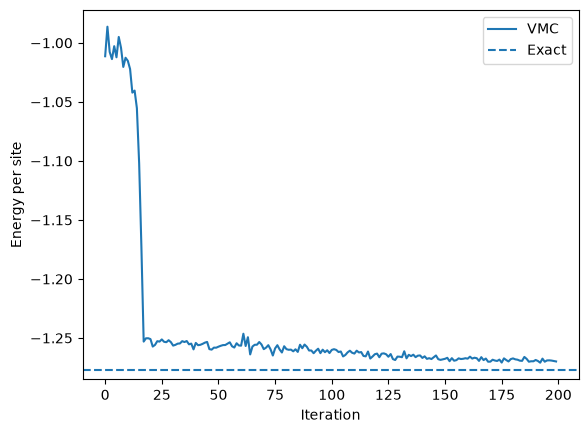

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(jnp.array(energies) / L, label="VMC")
plt.axhline(E_exact / L, linestyle="--", label="Exact")
plt.xlabel("Iteration")
plt.ylabel("Energy per site")
plt.legend()
plt.show()

### Stochastic Reconfiguration

So far, we have optimised the variational parameters using ordinary gradient descent,

$$\theta\leftarrow\theta-\eta \nabla E.$$

This update treats parameter space as a flat Euclidean space and ignores the fact that different parameter variations can have very different effects on the wavefunction.

In the lecture, we saw that the variational manifold is naturally equipped with a metric given by the covariance matrix of the logarithmic derivatives,

$$S_{ij} = \langle O_i O_j\rangle - \langle O_i\rangle \langle O_j\rangle.$$

Stochastic Reconfiguration (SR) uses this information to precondition the gradient and approximate imaginary-time evolution within the variational manifold. The update becomes

$$\theta \leftarrow \theta - \eta S^{-1}\nabla E.$$

The key observation is that nothing else in the VMC algorithm changes. We still:

1. generate samples from $|\psi_{\theta}|^2$,
2. compute local energies,
3. estimate the energy gradient.

Only the parameter update is modified.

In this notebook, we will use a helper function implementing the SR update and compare its convergence to ordinary gradient descent.

In [24]:
from cecam_nqs.optimizers import sr_precondition

n_iter = 200
learning_rate = 0.04
diag_shift = 0.01

energies_sr = []
sigma = sigma0
params_sr = params0

for it in range(n_iter):
    key, subkey = jax.random.split(key)

    samples, accepts, sigma = sample_mcmc(
        subkey,
        logpsi,
        params_sr,
        sigma,
        n_samples_per_chain,
    )

    samples_flat = samples.reshape(-1, L)

    energy, energy_error = energy_mc(params_sr, local_energy, g, samples_flat)
    grad, O = energy_gradient(
        params_sr,
        samples_flat,
        g,
        return_log_derivatives=True,
    )

    # ONLY DIFFERENCE: precondition the gradients by S^{-1}
    direction = sr_precondition(
        grad,
        O,
        diag_shift=diag_shift,
    )
    params_sr = apply_update(params_sr, direction, learning_rate)

    energies_sr.append(energy)

    if it % 10 == 0:
        print(
            f"it={it:03d} "
            f"E/L={energy / L:.6f} "
            f"err={energy_error / L:.6f} "
            f"acc={jnp.mean(accepts):.3f}"
        )

it=000 E/L=-1.014003 err=0.003203 acc=0.987
it=010 E/L=-1.269005 err=0.000378 acc=0.437
it=020 E/L=-1.275168 err=0.000196 acc=0.346
it=030 E/L=-1.275880 err=0.000145 acc=0.333
it=040 E/L=-1.276660 err=0.000108 acc=0.295
it=050 E/L=-1.276399 err=0.000102 acc=0.310
it=060 E/L=-1.277218 err=0.000090 acc=0.272
it=070 E/L=-1.276908 err=0.000097 acc=0.285
it=080 E/L=-1.276659 err=0.000092 acc=0.293
it=090 E/L=-1.276899 err=0.000087 acc=0.288
it=100 E/L=-1.276575 err=0.000086 acc=0.299
it=110 E/L=-1.277227 err=0.000088 acc=0.318
it=120 E/L=-1.276721 err=0.000079 acc=0.251
it=130 E/L=-1.276824 err=0.000083 acc=0.310
it=140 E/L=-1.276454 err=0.000081 acc=0.297
it=150 E/L=-1.276517 err=0.000079 acc=0.305
it=160 E/L=-1.276907 err=0.000075 acc=0.284
it=170 E/L=-1.276740 err=0.000071 acc=0.278
it=180 E/L=-1.276631 err=0.000073 acc=0.303
it=190 E/L=-1.276768 err=0.000068 acc=0.286


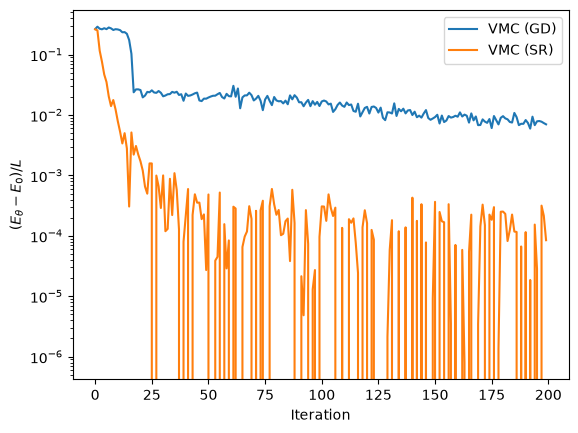

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.semilogy((jnp.array(energies) - E_exact) / L, label="VMC (GD)")
plt.semilogy((jnp.array(energies_sr) - E_exact) / L, label="VMC (SR)")
plt.xlabel("Iteration")
plt.ylabel(r"$(E_\theta - E_0) / L$")
plt.legend()
plt.show()

Pretty cool, huh?

## NetKet implementation

We have now implemented the full VMC loop by hand. NetKet provides these ingredients directly. The goal of this section is to show that the NetKet implementation follows exactly the same structure as our from-scratch code, but with the low-level details handled by the library.

In [26]:
import netket as nk
import flax.linen as nn
import jax.numpy as jnp

∣NK⟩ Tip: You can load logged data with nk.utils.history.HistoryDict.from_file(data.log).

In [27]:
# This defines the Hilbert space
hi = nk.hilbert.Spin(s=1 / 2, N=L)
print(hi)

# This defines the geometry of the lattice
graph = nk.graph.Chain(length=L, pbc=True)
print(graph)

# Transverse-field Ising is already implemented in pure JAX
ha = nk.operator.Ising(
    hilbert=hi,
    graph=graph,
    h=g,
)
print(ha)

Spin(s=1/2, N=12, ordering=new)
Chain(extent=[12], pbc=True)
IsingJax(J=1.0, h=1.0; dim=12)


In [28]:
from netket.models import RBM

# This defines the Ansatz as a flax.linen module
model = RBM(alpha=1)

# This is the standard Metropolis sampler with single spin-flip update rule
sampler = nk.sampler.MetropolisLocal(
    hilbert=hi,
    n_chains=n_chains,
)

# This defines the parameter update
optimizer = nk.optimizer.Sgd(learning_rate=learning_rate)

# This defines the SR preconditioner
sr = nk.optimizer.SR(diag_shift=diag_shift)

# The variational quantum state (VQS) hosts:
# - The model and its parameters, which it initialises automatically too
# - The sampler and the current sampler state, including the current state of the chains
vstate = nk.vqs.MCState(
    sampler=sampler,
    model=model,
    n_samples=n_chains * n_samples_per_chain,
)

# This sets up the optimisation driver
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=optimizer,
    variational_state=vstate,
    preconditioner=sr,
)

# This logs the optimisation in RAM
log = nk.logging.RuntimeLog()

Let us now run the ground-state search optimisation loop:

In [29]:
gs.run(
    n_iter=200,
    out=log,
)

  0%|                                                  | 0/200 [00:00<?, ?it/s]

(RuntimeLog():
  keys = ['Energy', 'acceptance', 'wallclock'],)

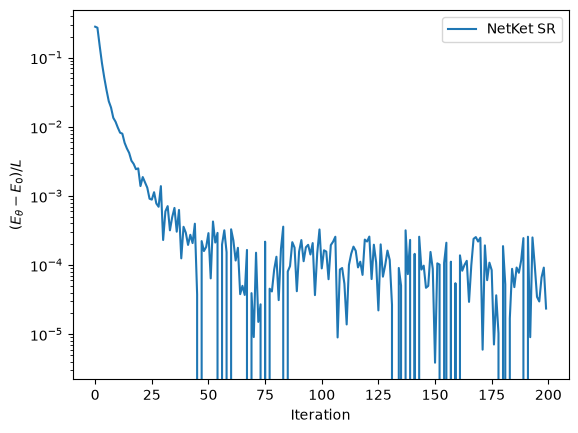

In [30]:
energies_sr_netket = jnp.array(log.data["Energy"]["Mean"])

plt.figure()
plt.semilogy((energies_sr_netket - E_exact) / L, label="NetKet SR")
plt.xlabel("Iteration")
plt.ylabel(r"$(E_\theta - E_0) / L$")
plt.legend()
plt.show()